# BTC/ETH: исследование торговых стратегий

**Период:** 27 сентября 2021 — 26 сентября 2026 UTC  
**Пополнения:** $100 ежемесячно, BTC 60% / ETH 40%, всего $6,000  
**Источник:** Binance Spot `BTCUSDT` и `ETHUSDT`, дневные OHLCV-свечи  

Notebook содержит воспроизводимые таблицы, графики, проверки реализации и rolling 5-year анализ устойчивости SMA 100/150/200/250/300.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
RESULTS = ROOT / "results"
DATA = ROOT / "data"
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print(f"Рабочая директория: {ROOT}")

Рабочая директория: /root/btc_eth_backtest


## Данные и контроль качества

Перед использованием проверяем диапазон дат, количество свечей, дубликаты и пропуски. Прогрев индикаторов начинается 1 января 2020 года и не включается в доходность.

In [2]:
data_checks=[]
for path in sorted(DATA.glob("*usdt_1d.csv")):
    df=pd.read_csv(path, parse_dates=["open_time"])
    gaps=(df.open_time.diff().dropna()!=pd.Timedelta(days=1)).sum()
    data_checks.append({
        "file":path.name, "rows":len(df), "first":df.open_time.min(),
        "last":df.open_time.max(), "duplicates":int(df.open_time.duplicated().sum()), "gaps":int(gaps)
    })
data_checks=pd.DataFrame(data_checks)
display(data_checks)
assert (data_checks.duplicates==0).all() and (data_checks.gaps==0).all()
print("Проверка данных пройдена: пропусков и дубликатов нет.")

,file,rows,first,last,duplicates,gaps
0,btcusdt_1d.csv,2461,2020-01-01 00:00:00+00:00,2026-09-26 00:00:00+00:00,0,0
1,ethusdt_1d.csv,2461,2020-01-01 00:00:00+00:00,2026-09-26 00:00:00+00:00,0,0


Проверка данных пройдена: пропусков и дубликатов нет.


## Итоговая таблица стратегий

Комиссия — 0,10% на сторону, проскальзывание — 0,05% на сторону. Сигнал рассчитывается по закрытию завершённой свечи и исполняется по открытию следующего дня. Max DD рассчитан по time-weighted индексу, исключающему внешние пополнения.

In [3]:
summary=pd.read_csv(RESULTS/"summary.csv")
total=summary[summary.asset=="TOTAL"].copy()
total["strategy"]=total.strategy.replace({
    "DCA_REBALANCE":"DCA + monthly rebalance",
    "DCA_SMA200_EXIT":"DCA + SMA200 exit",
    "DCA_REBALANCE_SMA200_EXIT":"DCA + rebalance + SMA200 exit"
})
cols=["strategy","final_value","profit","return_pct","xirr","max_drawdown","trades","fees","slippage"]
display(total[cols].sort_values("final_value",ascending=False).style.format({
    "final_value":"${:,.2f}","profit":"${:,.2f}","return_pct":"{:.2%}","xirr":"{:.2%}","max_drawdown":"{:.2%}","fees":"${:,.2f}","slippage":"${:,.2f}"
}))

,strategy,final_value,profit,return_pct,xirr,max_drawdown,trades,fees,slippage
5,SMA200,"$11,365.43","$5,365.43",89.42%,25.85%,-35.56%,129,$206.85,$103.42
22,DCA + SMA200 exit,"$11,365.43","$5,365.43",89.42%,25.85%,-35.56%,129,$206.85,$103.42
21,DCA + monthly rebalance,"$10,105.50","$4,105.50",68.42%,20.97%,-76.23%,120,$15.37,$7.69
2,DCA,"$10,041.37","$4,041.37",67.36%,20.71%,-76.52%,120,$5.99,$3.00
11,Momentum90,"$9,897.79","$3,897.79",64.96%,20.11%,-56.36%,192,$249.17,$124.59
23,DCA + rebalance + SMA200 exit,"$7,841.60","$1,841.60",30.69%,10.64%,-41.84%,84,$82.32,$41.16
8,SMA50_200,"$7,334.33","$1,334.33",22.24%,7.96%,-47.04%,80,$44.52,$22.26
14,Donchian20_10,"$6,420.30",$420.30,7.00%,2.67%,-44.70%,164,$210.97,$105.48
17,RSI14,"$6,133.81",$133.81,2.23%,0.87%,-46.40%,83,$54.85,$27.43
20,Bollinger20_2,"$5,268.03",$-731.97,-12.20%,-5.10%,-50.70%,161,$213.71,$106.85


### Вывод

На основном пятилетнем периоде лучшими по итоговой стоимости стали SMA 200 и эквивалентный ей вариант DCA с выходом по SMA 200. Их преимущество над обычным DCA сопровождается гораздо большим оборотом и торговыми издержками. Обычная ежемесячная ребалансировка дала лишь небольшое улучшение.

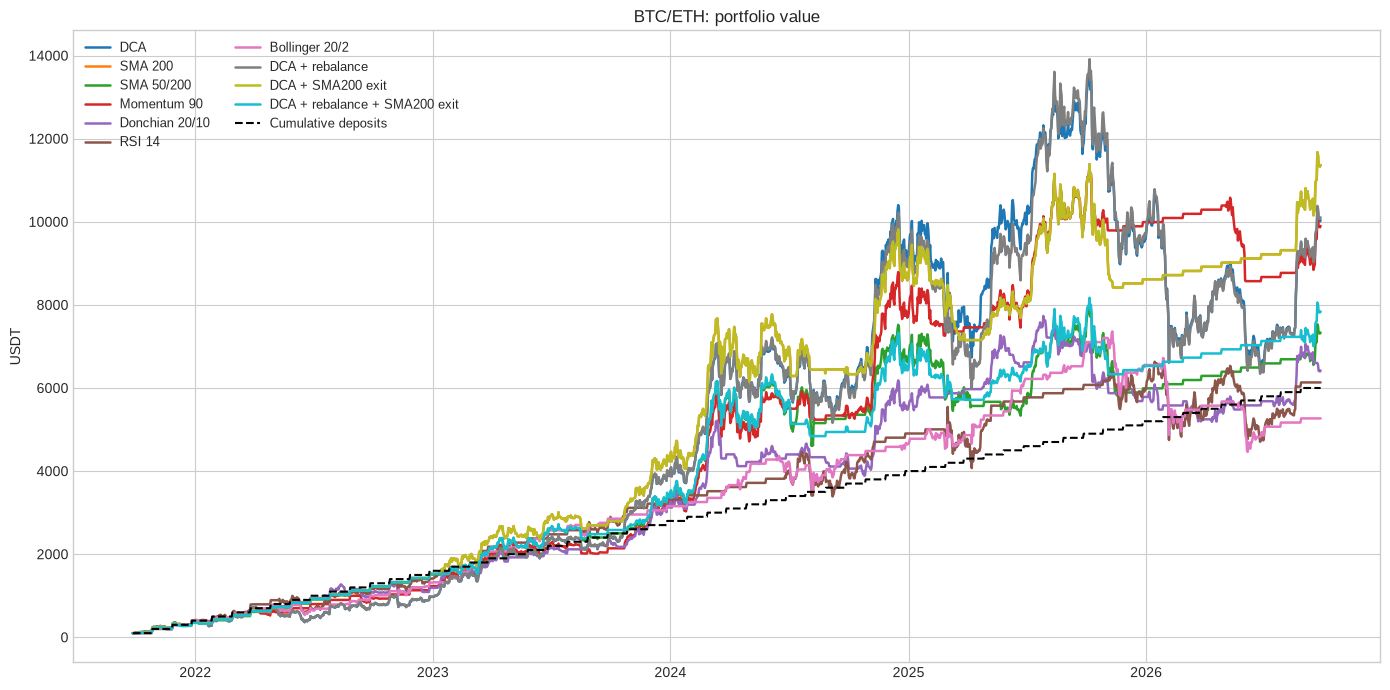

In [4]:
strategies=["DCA","SMA200","SMA50_200","Momentum90","Donchian20_10","RSI14","Bollinger20_2","DCA_REBALANCE","DCA_SMA200_EXIT","DCA_REBALANCE_SMA200_EXIT"]
labels={"DCA":"DCA","SMA200":"SMA 200","SMA50_200":"SMA 50/200","Momentum90":"Momentum 90","Donchian20_10":"Donchian 20/10","RSI14":"RSI 14","Bollinger20_2":"Bollinger 20/2","DCA_REBALANCE":"DCA + rebalance","DCA_SMA200_EXIT":"DCA + SMA200 exit","DCA_REBALANCE_SMA200_EXIT":"DCA + rebalance + SMA200 exit"}
fig,ax=plt.subplots(figsize=(14,7))
for s in strategies:
    q=pd.read_csv(RESULTS/f"equity_{s}_TOTAL.csv",parse_dates=["date"])
    ax.plot(q.date,q.equity,label=labels[s],lw=1.8)
q=pd.read_csv(RESULTS/"equity_DCA_TOTAL.csv",parse_dates=["date"])
ax.plot(q.date,q.deposit.cumsum(),"k--",lw=1.5,label="Cumulative deposits")
ax.set_title("BTC/ETH: portfolio value")
ax.set_ylabel("USDT")
ax.legend(ncol=2,fontsize=9)
plt.tight_layout(); plt.show()

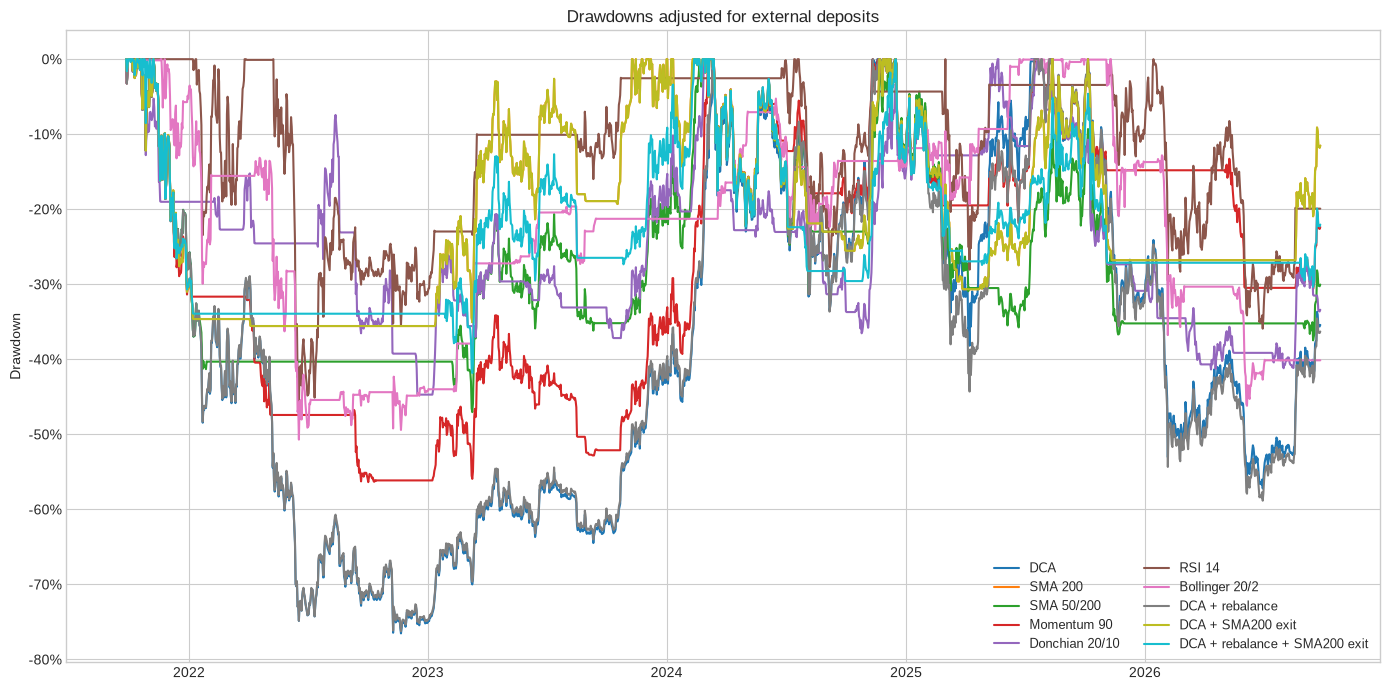

In [5]:
fig,ax=plt.subplots(figsize=(14,7))
for s in strategies:
    q=pd.read_csv(RESULTS/f"equity_{s}_TOTAL.csv",parse_dates=["date"])
    ax.plot(q.date,q.drawdown,label=labels[s],lw=1.5)
ax.set_title("Drawdowns adjusted for external deposits")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(lambda x,pos:f"{x:.0%}")
ax.legend(ncol=2,fontsize=9)
plt.tight_layout(); plt.show()

## Устойчивость длины SMA

Проверены SMA 100, 150, 200, 250 и 300 на перекрывающихся пятилетних окнах с ежемесячным сдвигом даты старта. Доступный набор данных начинается 1 января 2020 года, поэтому первое полное окно начинается 27 января 2020 года; окон 2018–2019 нет.

,window,windows,win_rate,median_difference_pct,mean_difference_pct,median_max_dd,mean_max_dd,median_trades
0,100,21,38.1%,-4.50%,-1.52%,-54.71%,-53.48%,223.000000
1,150,21,76.2%,15.33%,13.54%,-53.35%,-49.34%,155.000000
2,200,21,57.1%,3.91%,5.99%,-50.73%,-47.22%,143.000000
3,250,21,19.0%,-11.02%,-9.92%,-53.20%,-50.96%,158.000000
4,300,21,23.8%,-11.73%,-6.05%,-55.79%,-56.01%,148.000000


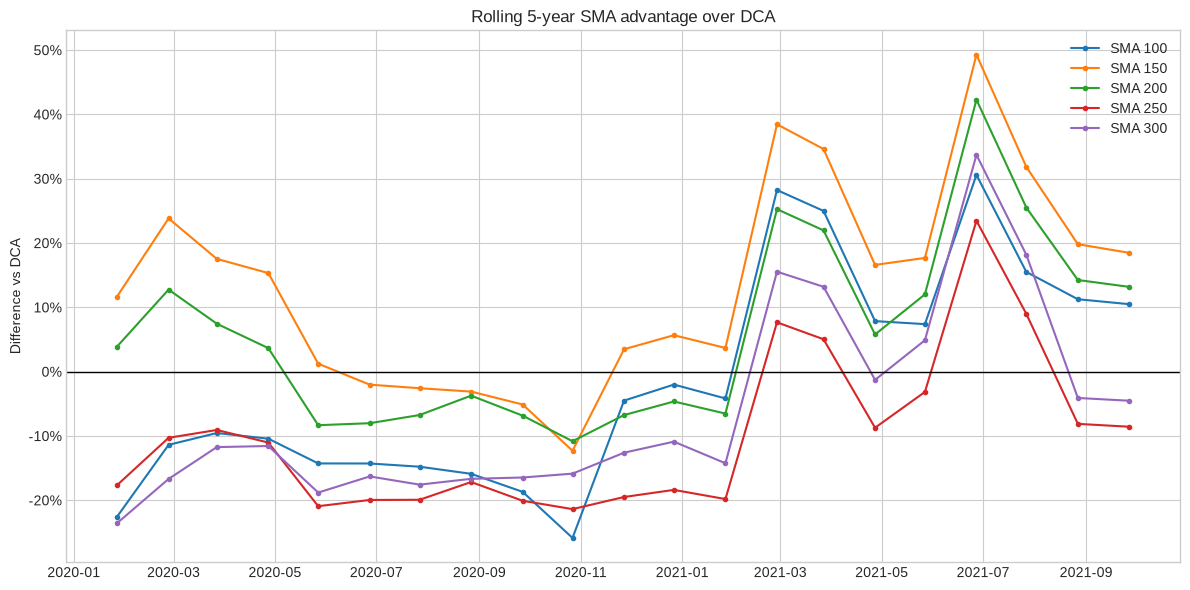

In [6]:
roll=pd.read_csv(RESULTS/"rolling_5y_results.csv")
roll_summary=pd.read_csv(RESULTS/"rolling_5y_summary.csv")
display(roll_summary.style.format({"win_rate":"{:.1%}","median_difference_pct":"{:.2%}","mean_difference_pct":"{:.2%}","median_max_dd":"{:.2%}","mean_max_dd":"{:.2%}"}))
fig,ax=plt.subplots(figsize=(12,6))
for w,g in roll.groupby("window"):
    g=g.sort_values("start")
    ax.plot(pd.to_datetime(g.start),g.difference_pct,marker="o",ms=3,label=f"SMA {w}")
ax.axhline(0,color="black",lw=1)
ax.set_title("Rolling 5-year SMA advantage over DCA")
ax.set_ylabel("Difference vs DCA")
ax.yaxis.set_major_formatter(lambda x,pos:f"{x:.0%}")
ax.legend()
plt.tight_layout(); plt.show()

### Вывод по rolling-тесту

SMA 150 показала наиболее устойчивое поведение: она превзошла DCA в 76,2% окон, а медианная разница составила +15,33%. SMA 200 выиграла в 57,1% окон с медианной разницей +3,91%. Это не доказывает универсальность SMA 150: окна пересекаются и не являются независимыми наблюдениями, а выбор параметра по всей выборке был бы look-ahead bias.

In [7]:
audit=pd.read_csv(RESULTS/"audit_signal_checks.csv")
comparison=pd.read_csv(RESULTS/"audit_trade_comparison.csv")
print("Покупок комбинированной стратегии вопреки собственному SMA 200:", int((~audit.buy_signal_bullish).sum()))
display(comparison[["asset","side","sma200_count","dca_sma200_count","same_signal_dates","rebalance_exit_count"]])
print("\nПервые расхождения позиций:")
display(pd.read_csv(RESULTS/"audit_position_divergence.csv").groupby("asset").first())

Покупок комбинированной стратегии вопреки собственному SMA 200: 0


,asset,side,sma200_count,dca_sma200_count,same_signal_dates,rebalance_exit_count
0,BTC,BUY,54,54,True,29
1,BTC,SELL,19,19,True,19
2,ETH,BUY,42,42,True,25
3,ETH,SELL,14,14,True,11



Первые расхождения позиций:


,first_divergence_date,sma200_units,combined_units
asset,,,
BTC,2021-10-02 00:00:00+00:00,0.00,0.00
ETH,2021-10-27 00:00:00+00:00,0.02,0.02


## Итоговые выводы и ограничения

1. На периоде 27.09.2021–26.09.2026 SMA 200 увеличила итоговый портфель относительно DCA на 13,19% и снизила Max DD с 76,52% до 35,56%.
2. Это преимущество зависит от даты старта: на периоде 2020–2025 SMA 200 уступила DCA на 6,83%.
3. Rolling 5-year анализ показывает, что SMA 150 была устойчивее SMA 200 в доступных окнах, но результаты окон коррелированы.
4. Данные начинаются только с 2020 года, поэтому мартовский обвал 2020 включён лишь в поздние части первого rolling-окна, а окна 2018–2019 недоступны.
5. USDT оценивается условно как $1; модель не учитывает отклонение USDT от USD, bid/ask spread, частичные исполнения и налоги.

Полный код, сырые свечи, журналы сделок, дневные equity, тесты и графики находятся в этом репозитории.